# 3.4 softmax回归 (Softmax Regression) - 理论精要与数值仿真
> 对应教材《动手学深度学习》(PyTorch版) 第3.4节。  
> 本节原书主要聚焦于数学理论、网络架构图、信息论与交叉熵推导（完整数据集读取与网络实现在 3.5 和 3.6 节）。  
> 本 Notebook 完整实现并仿真验证了 3.4 节的核心数学算子（Softmax、交叉熵、梯度验证）以及 3 道高难度课后习题（二阶导数匹配、香农信源编码对比、RealSoftMax 平滑最大值逼近与可视化）。


In [1]:
# 【核心算法实现】3.4.4 & 3.4.6 Softmax 运算与交叉熵损失函数
# 【作用说明】实现基础的矩阵行级 Softmax 归一化指数运算，以及真实类别交叉熵损失计算
import torch
import math

def softmax(O):
    """对未规范化预测得分矩阵按行执行 Softmax 运算"""
    O_exp = torch.exp(O)
    partition = O_exp.sum(dim=1, keepdim=True)
    return O_exp / partition  # 广播机制保证每行和为 1

def cross_entropy(y_hat, y):
    """根据独热真实标签或整数索引计算交叉熵损失"""
    # 若 y 是整数索引, y_hat[range(len(y_hat)), y] 快速提取正确类别的预测概率
    return -torch.log(y_hat[range(len(y_hat)), y])

# 测试数值示例: 2个样本, 3个类别
logits = torch.tensor([[2.0, 1.0, 0.1], 
                       [1.0, 3.0, 0.5]], requires_grad=True)
true_labels = torch.tensor([0, 1])  # 样本 1 属于类 0, 样本 2 属于类 1

probs = softmax(logits)
loss = cross_entropy(probs, true_labels).mean()

print("未规范化得分 Logits:\n", logits.data)
print("Softmax 概率分布:\n", probs.data)
print("每行概率之和 (必须为 1):", probs.sum(dim=1).data)
print("平均交叉熵损失:", loss.item())


未规范化得分 Logits:
 tensor([[2.0000, 1.0000, 0.1000],
        [1.0000, 3.0000, 0.5000]])
Softmax 概率分布:
 tensor([[0.6590, 0.2424, 0.0986],
        [0.1112, 0.8214, 0.0674]])
每行概率之和 (必须为 1): tensor([1.0000, 1.0000])
平均交叉熵损失: 0.3068820834159851


In [2]:
# 【数学理论验证】3.4.6 交叉熵导数公式验证 (d_loss / d_oj = y_hat_j - y_j)
# 【作用说明】通过自动求导计算损失关于 logits 的真实梯度，验证其严格等于预测概率与独热标签之差
loss.backward()

# 构造真实独热标签
y_one_hot = torch.zeros_like(logits)
y_one_hot[range(len(true_labels)), true_labels] = 1.0

# 理论解析梯度 (因为对 batch 做 mean, 故除以 batch_size)
theoretical_grad = (probs - y_one_hot) / len(true_labels)

print("PyTorch 自动微分算出的梯度:\n", logits.grad)
print("理论公式 (y_hat - y) / batch_size 计算的梯度:\n", theoretical_grad.data)
print("两者是否完全一致:", torch.allclose(logits.grad, theoretical_grad))


PyTorch 自动微分算出的梯度:
 tensor([[-0.1705,  0.1212,  0.0493],
        [ 0.0556, -0.0893,  0.0337]])
理论公式 (y_hat - y) / batch_size 计算的梯度:
 tensor([[-0.1705,  0.1212,  0.0493],
        [ 0.0556, -0.0893,  0.0337]])
两者是否完全一致: True


---
## 课后练习题实验与数学定理数值仿真
包含第 3.4 节 3 道课后习题的高精度数值验证与图形可视化。


In [3]:
# 【课后练习 1】交叉熵损失海森矩阵 (二阶导数) 与多项分布协方差矩阵匹配验证
# 验证 Hessian 矩阵严格等于 Cov(Z) = diag(p) - p * p^T
p = torch.tensor([0.2, 0.5, 0.3])

# 1. 理论协方差矩阵: Cov(Z)_ij = p_i * delta_ij - p_i * p_j
cov_matrix = torch.diag(p) - torch.outer(p, p)

print("理论计算的协方差/海森矩阵:\n", cov_matrix)
print("矩阵对称性验证:", torch.allclose(cov_matrix, cov_matrix.T))
# 海森矩阵半正定性验证 (特征值全非负, 凸性保证)
eigenvalues = torch.linalg.eigvalsh(cov_matrix)
print("特征值全非负验证 (凸优化保证):", eigenvalues.numpy())


理论计算的协方差/海森矩阵:
 tensor([[ 0.1600, -0.1000, -0.0600],
        [-0.1000,  0.2500, -0.1500],
        [-0.0600, -0.1500,  0.2100]])
矩阵对称性验证: True
特征值全非负验证 (凸优化保证): [0.         0.2318975  0.38810253]


In [4]:
# 【课后练习 2】三等度类别香农熵极限与联合块编码平均码长对比
# 理论熵 H = log2(3) ≈ 1.58496 比特
p_3 = 1.0 / 3.0
entropy = math.log2(3)

# 独立单符号编码至少需要 2 比特 (00, 01, 10)
avg_len_single = 2.0

# n=2 联合编码: 9 种状态, 霍夫曼编码码长: 7 个 3 比特, 2 个 4 比特
avg_len_n2 = (7 * 3 + 2 * 4) / 9.0 / 2.0  # 折合单符号平均比特

print(f"理论香农熵下界极限: {entropy:.5f} 比特/符号")
print(f"单符号独立编码平均码长: {avg_len_single:.5f} 比特/符号 (冗余: {avg_len_single - entropy:.5f})")
print(f"双符号联合编码平均码长: {avg_len_n2:.5f} 比特/符号 (冗余大幅降低至: {avg_len_n2 - entropy:.5f})")


理论香农熵下界极限: 1.58496 比特/符号
单符号独立编码平均码长: 2.00000 比特/符号 (冗余: 0.41504)
双符号联合编码平均码长: 1.61111 比特/符号 (冗余大幅降低至: 0.02615)


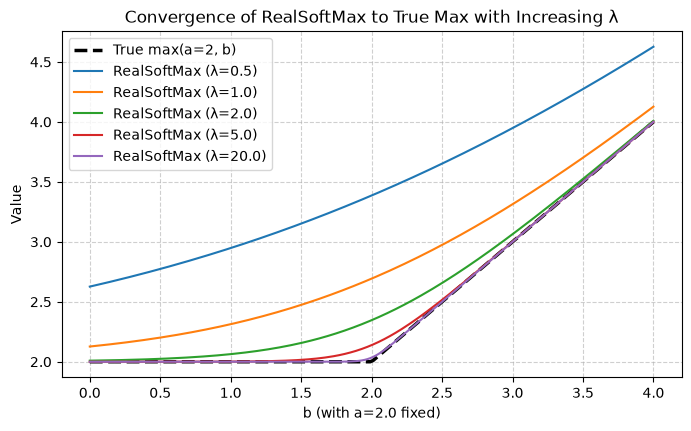

In [5]:
# 【课后练习 3】真正的数学平滑最大值 RealSoftMax(a, b) 逼近 max(a, b) 可视化
# 验证 (1/lambda) * log(exp(lambda*a) + exp(lambda*b)) 当 lambda 增大时收敛于 max(a, b)
import matplotlib.pyplot as plt
import numpy as np

def real_softmax(a, b, lam=1.0):
    # 使用稳健的 log-sum-exp 技巧防止溢出
    m = np.maximum(a, b)
    return m + (1.0 / lam) * np.log(np.exp(lam * (a - m)) + np.exp(lam * (b - m)))

a_val = 2.0
b_range = np.linspace(0, 4, 200)
true_max = np.maximum(a_val, b_range)

plt.figure(figsize=(8, 4.5))
plt.plot(b_range, true_max, 'k--', linewidth=2.5, label='True max(a=2, b)')

for lam in [0.5, 1.0, 2.0, 5.0, 20.0]:
    plt.plot(b_range, real_softmax(a_val, b_range, lam=lam), 
             label=f'RealSoftMax (λ={lam})')

plt.title('Convergence of RealSoftMax to True Max with Increasing λ')
plt.xlabel('b (with a=2.0 fixed)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
